Import Dependencies

In [1]:
from core.ai_insights import Advisor
from core.forecaster import Forecaster
from core.models import american_system
from core.data_loader import DataLoader
from core.analyzer import Analyzer
from core.visualiser import visualiser

Load Grades

In [2]:
# Current results
loader = DataLoader('test_data/my grades.csv')
data = loader.data()

# What-if grades
loader_ = DataLoader('test_data/my what-if.csv')
data_ = loader_.load()

Analyze grades for GPA and CGPA

Current CGPA: 3.2


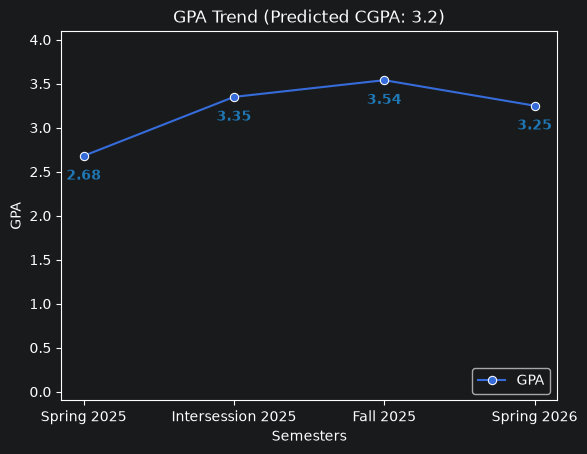

In [3]:
# Calculate CGPA and get GPA Trend
analyzer = Analyzer(data=data, grading_system=american_system)
print(f'Current CGPA: {analyzer.cgpa()}')
visualiser(analyzer, american_system.max_gpa) # Look at GPA Trend

What-if and Next Target Analysis

In [4]:
forecaster = Forecaster(analyzer, grading_system=american_system)

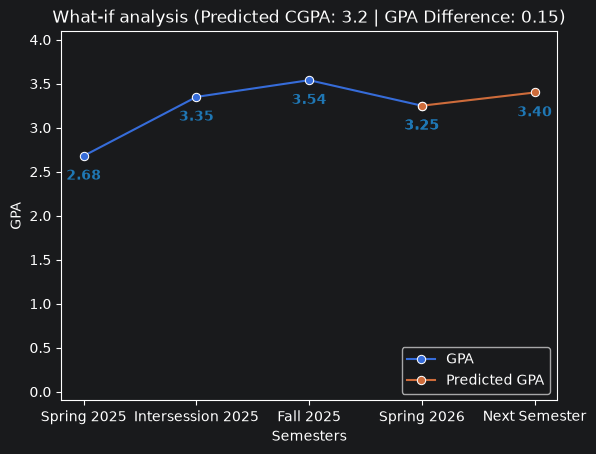

What if analysis: {'expected_gpa': 3.4, 'expected_cgpa': 3.25}


In [5]:
#what if
wha_if_grades = data_['Grade'].to_list()
wha_if_units = data_['Units'].to_list()
print(f"What if analysis: {forecaster.what_if(wha_if_grades, wha_if_units, visualise=True)}")

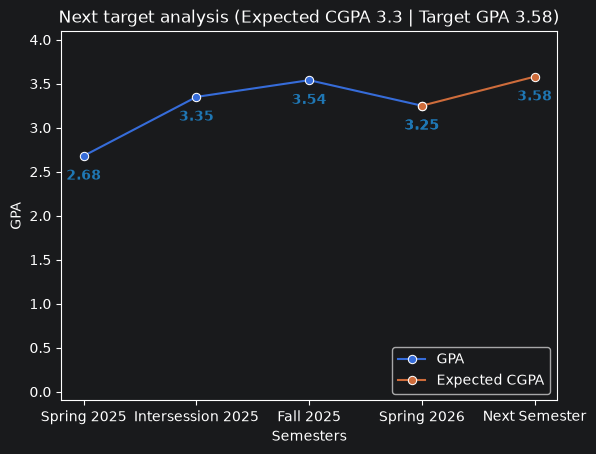

Next target analysis: If you want to get a CGPA of 3.3, you must get a GPA of 3.58.


In [6]:
#next target
next_target = forecaster.next_target(3.3, 18, visualise=True)
if type(next_target) == dict:
    print(f"Next target analysis: If you want to get a CGPA of {next_target.get('expected_cgpa')}, you must get a GPA of {next_target.get('expected_gpa')}.")
else:
    print(next_target)

AI Powered Insights

In [7]:
# AI insights
advisor = Advisor(analyzer, forecaster)

In [ ]:
subject_analysis_response = advisor.subject_analysis()
print(subject_analysis_response)

In [ ]:
pr = advisor.progress_report(132)
print(pr)

In [9]:
wi = advisor.what_if(wha_if_grades, wha_if_units)
print(wi)

Hitting that **3.40** semester GPA you're aiming for is a great target to shoot for. Pulling off a term like that shifts your trajectory upward, raising your overall CGPA from a **3.20** to a **3.25**. It's a solid step forward, proving that consistent, strong semesters really do pay off in the long run!


In [ ]:
sr = advisor.semester_review()
print(sr)

In [ ]:
gs = advisor.goal_seeker(80, 'Magna Cum Laude')
print(gs)